# Supervised Learning in Return Expectations

### Group A: QQQ (Direction Classification) & Group B: 10-Year Treasury Yield (1-Month Change Classification)

**Author:** Ugo Janssen

---

**Overview.** This notebook implements the full workflow for a supervised learning exercise
in short-term return prediction, following the structure below. Two
independent classification tasks are addressed:

- **Group A — QQQ:** binomial classification of next-day price direction (up/down), using
daily OHLCV data.
- **Group B — ^TNX (10-Year Treasury Yield):** multinomial classification of 1-month yield
change, bucketed into down/flat/up terciles.

Both tasks use logistic regression with L1 (Lasso) and L2 (Ridge) regularisation, features
engineered from Table 1 of the assignment brief (O-C, H-L, sign of return, lagged returns,
momentum, SMA, EMA), and are evaluated with confusion matrices, ROC-AUC, and precision/recall.

Short-term returns in efficient markets are not expected to be strongly predictable. The aim of this project is to present a theoretically grounded approach and to demonstrate correct methodology and honest evaluation, rather than to claim a practical trading edge in real-world markets.

**Structure:**

1. Data Acquisition and Initial Review (QQQ & ^TNX)
2. Feature Construction: Group A and Group B
3. The Logistic Classifier and Its Formulation
    - Mathematical Basis of Ridge and Lasso Regularisation
    - Implementation and Coefficient Comparison (Group A & B)
    - Bias and Variance: L1 vs. L2
4. Model Selection and Evaluation
    - Scaling Comparison (Min Max vs. Robust)
    - Collinearity and Feature Selection (VIF)
    - Sigmoid Analysis
    - Evaluation Metrics (Confusion Matrix, ROC AUC, Precision/Recall)
5. Mathematical Bases of Supervised Learning and Conclusion


## Setup

Import the libraries used throughout: `pandas`/`numpy` for data handling, `yfinance` for
market data, `scikit-learn` for the logistic regression models and evaluation metrics, and
`statsmodels` for the VIF collinearity check used later on.

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import collections
import seaborn as sns
import yfinance as yf
import io
import base64
import IPython.display as display

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler, label_binarize
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV, cross_val_score, TimeSeriesSplit
from sklearn.metrics import (roc_curve, auc, roc_auc_score, confusion_matrix, classification_report, precision_score, recall_score)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from IPython.display import display_html
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import brentq

import warnings
warnings.filterwarnings("ignore")

## Data Acquisition

Pull daily OHLCV (Open/High/Low/Close/Volume) price data for both tickers from 2005 onward —
far enough back to include multiple market regimes (2008 financial crisis, 2020 COVID crash,
2022 rate-hiking cycle) without reaching into the early, thinner-history years of QQQ's
listing. `auto_adjust=False` is used deliberately to keep the raw, as-traded prices rather
than dividend/split-adjusted values, since the engineered features below (O-C, H-L,
momentum) are defined on actual traded prices.

In [43]:
qqq = yf.download("QQQ", start="2005-01-01", progress=False, auto_adjust=False)
tnx = yf.download("^TNX", start="2005-01-01", progress=False, auto_adjust=False)

qqq = qqq[["Open", "High", "Low", "Close", "Volume"]].dropna()
tnx = tnx[["Open", "High", "Low", "Close", "Volume"]].dropna()

print("QQQ:", qqq.shape, qqq.index.min(), "to", qqq.index.max())
print("^TNX:", tnx.shape, tnx.index.min(), "to", tnx.index.max())

qqq.tail()

QQQ: (5421, 5) 2005-01-03 00:00:00 to 2026-07-22 00:00:00
^TNX: (5416, 5) 2005-01-03 00:00:00 to 2026-07-22 00:00:00


Price,Open,High,Low,Close,Volume
Ticker,QQQ,QQQ,QQQ,QQQ,QQQ
Date,,,,,
2026-07-16,712.010010,713.599976,702.609985,705.940002,39402000
2026-07-17,691.650024,702.299988,686.760010,695.330017,54109300
2026-07-20,702.159973,705.799988,695.510010,696.059998,29687600
2026-07-21,706.570007,710.049988,702.799988,708.969971,33728300
2026-07-22,703.619995,709.647278,703.640015,705.349976,20691249


## Exploratory Data Analysis

Before building any features, the raw QQQ and ^TNX series are inspected for gaps, missing
dates, and anomalies, and their Close prices are plotted for a first visual check.

**QQQ** tracks the Nasdaq-100 and shows the expected long-run upward trend over the sample
period, with visible drawdowns during the 2008 and 2020 crises. **^TNX** represents the
10-year US Treasury yield (in percentage points), and reflects the post-2008 low-rate
environment, the near-zero yields of 2020–21, and the sharp rise through 2022–23 as the Fed
raised rates. Both series look clean, with no unexplained gaps or anomalous values.

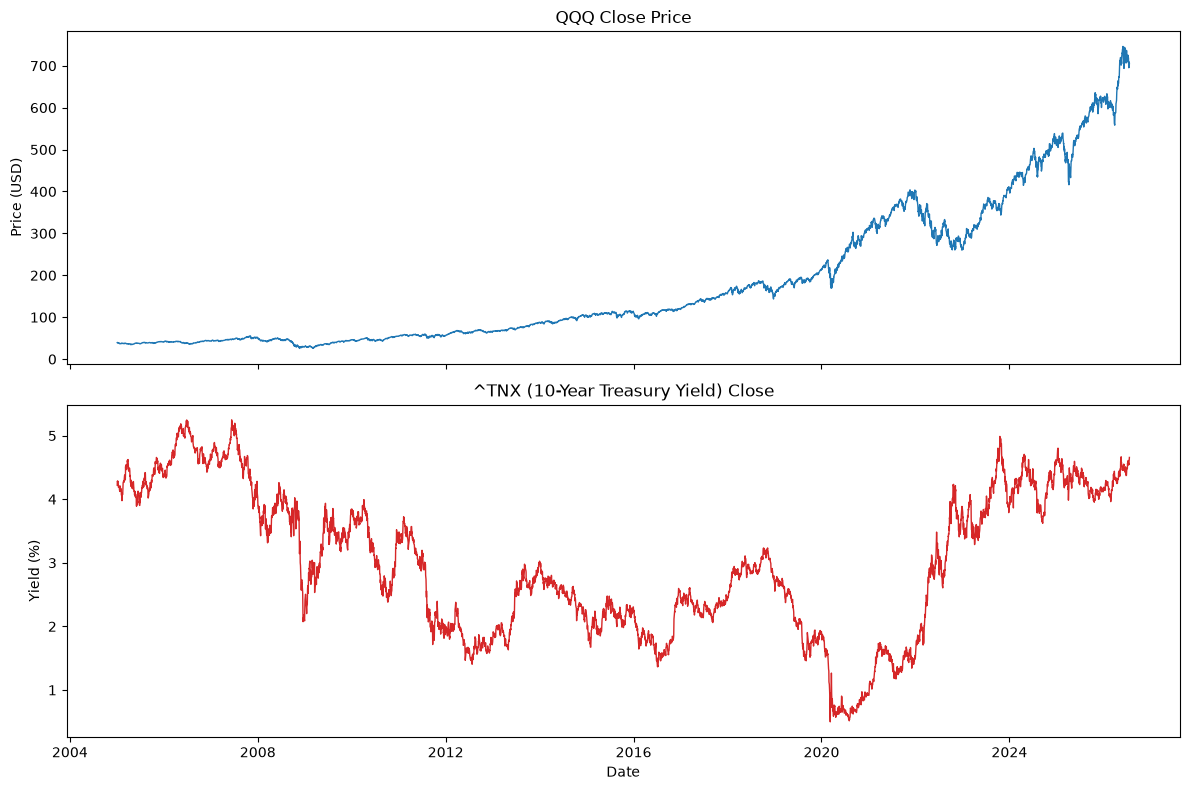

In [44]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(qqq.index, qqq["Close"], color="tab:blue", linewidth=1)
axes[0].set_title("QQQ Close Price")
axes[0].set_ylabel("Price (USD)")

axes[1].plot(tnx.index, tnx["Close"], color="tab:red", linewidth=1)
axes[1].set_title("^TNX (10-Year Treasury Yield) Close")
axes[1].set_ylabel("Yield (%)")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

### Daily Returns

Both series start from a daily change measure, but computed differently to suit each
asset's nature. For **QQQ**, a **percentage return** is natural for a price series:

$$ r_t = \frac{P_t - P_{t-1}}{P_{t-1}} $$

For **^TNX**, which is already a percentage (a yield level), a percentage-change-of-a-percentage
is not meaningful. Particularly when yields sit near zero, as in 2020–21. A plain **level
change** is used instead:

$$ \Delta y_t = y_t - y_{t-1} $$

In [45]:
qqq["return"] = qqq["Close"].pct_change()
tnx["change"] = tnx["Close"].diff()

qqq_view = qqq[["Close", "return"]].head(5)
tnx_view = tnx[["Close", "change"]].head(5)

html = (
    '<div style="display:flex; gap:60px;">'
    f'<div><b>QQQ — Daily Returns</b>{qqq_view.to_html()}</div>'
    f'<div><b>^TNX — Daily Changes</b>{tnx_view.to_html()}</div>'
    '</div>'
)
display_html(html, raw=True)

Price,Close,return
Ticker,QQQ,
Date,,
2005-01-03,39.500000,NaN
2005-01-04,38.779999,-0.018228
2005-01-05,38.540001,-0.006189
2005-01-06,38.349998,-0.004930
2005-01-07,38.549999,0.005215
Price,Close,change
Ticker,^TNX,
Date,,


### Group A Target: Next-Day Direction

The prediction target is *tomorrow's* direction, placed on today's row so each row pairs
"what is known today" with "what is being predicted":

$$ y_t = \mathbb{1}[r_{t+1} > 0] \in \{0, 1\} $$

where $y_t = 1$ denotes an up day and $y_t = 0$ a down day. Near-zero moves fall into the
"down" bucket under this threshold, a data-driven choice, per the assignment's guidance,
rather than treating them as a separate class.

In [46]:
qqq["target_return"] = qqq["return"].shift(-1)
qqq["target_direction"] = (qqq["target_return"] > 0).astype(int)

qqq[["Close", "return", "target_return", "target_direction"]].head(10)

Price,Close,return,target_return,target_direction
Ticker,QQQ,,,
Date,,,,
2005-01-03,39.500000,NaN,-0.018228,0
2005-01-04,38.779999,-0.018228,-0.006189,0
2005-01-05,38.540001,-0.006189,-0.004930,0
2005-01-06,38.349998,-0.004930,0.005215,1
2005-01-07,38.549999,0.005215,-0.000519,0
2005-01-10,38.529999,-0.000519,-0.007008,0
2005-01-11,38.259998,-0.007008,0.008364,1
2005-01-12,38.580002,0.008364,-0.013219,0


### Group B Target: 1-Month Change, Bucketed

Group B predicts a longer horizon (approximately one calendar month), taken as 21 trading
days ahead:

$$ \Delta y_t^{(1M)} = y_{t+21} - y_t $$

Rather than assume arbitrary thresholds for classifying this change, its distribution is
inspected directly and split into terciles, giving three roughly equal-sized classes:

$$ q_1 = Q_{0.33}\big(\Delta y^{(1M)}\big), \qquad q_2 = Q_{0.67}\big(\Delta y^{(1M)}\big) $$

$$
y_t =
\begin{cases}
0 \ (\text{down}) & \Delta y_t^{(1M)} \le q_1 \\
1 \ (\text{flat}) & q_1 < \Delta y_t^{(1M)} < q_2 \\
2 \ (\text{up}) & \Delta y_t^{(1M)} \ge q_2
\end{cases}
$$

This turns Group B into a multinomial classification problem, as recommended in the brief.

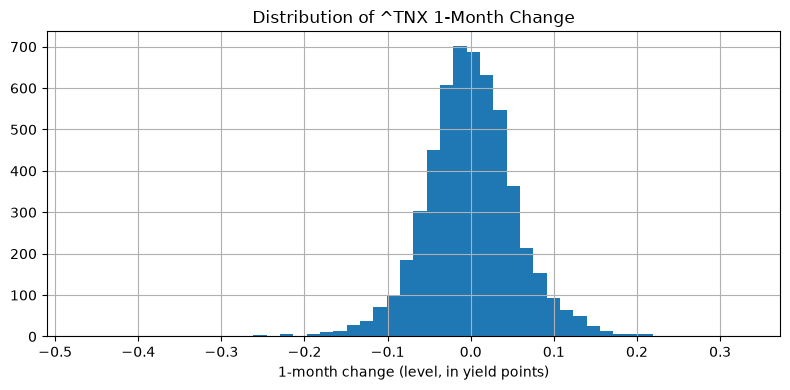

In [47]:
# Forward 1-month change
tnx["target_change_1m"] = tnx["change"].shift(-21)

# Inspect distribution before choosing cutoffs
tnx["target_change_1m"].hist(bins=50, figsize=(8, 4))
plt.title("Distribution of ^TNX 1-Month Change")
plt.xlabel("1-month change (level, in yield points)")
plt.tight_layout()
plt.show()

# Tercile cutoffs
q1 = tnx["target_change_1m"].quantile(1/3)
q2 = tnx["target_change_1m"].quantile(2/3)

# Bucket into 3 classes
def bucket_label(x):
    if x <= q1:
        return 0   # down
    elif x >= q2:
        return 2   # up
    else:
        return 1   # flat

tnx["target_bucket"] = tnx["target_change_1m"].apply(bucket_label)

In [48]:
desc = tnx["target_change_1m"].describe()
class_counts = tnx["target_bucket"].value_counts().sort_index()

left_text = "Descriptive statistics:<br>"
for stat, val in desc.items():
    left_text += f"&nbsp;&nbsp;{stat}: {val:.4f}<br>"
left_text += f"<br>Lower cutoff (33rd pct): {q1:.4f}<br>"
left_text += f"Upper cutoff (67th pct): {q2:.4f}<br>"
left_text += "<br>Class balance:<br>"
for cls, count in class_counts.items():
    left_text += f"&nbsp;&nbsp;Class {cls}: {count}<br>"

right_table = tnx[["Close", "change", "target_change_1m", "target_bucket"]].head(10).to_html()

In [49]:
html = (
    '<div style="display:flex; gap:60px; align-items:flex-start; font-family:monospace;">'
    f'<div>{left_text}</div>'
    f'<div>{right_table}</div>'
    '</div>'
)
display_html(html, raw=True)

Price,Close,change,target_change_1m,target_bucket
Ticker,^TNX,,,
Date,,,,
2005-01-03,4.220,NaN,0.004,1
2005-01-04,4.283,0.063,0.023,2
2005-01-05,4.277,-0.006,-0.090,0
2005-01-06,4.272,-0.005,-0.021,1
2005-01-07,4.285,0.013,-0.015,1
2005-01-10,4.278,-0.007,-0.060,0
2005-01-11,4.244,-0.034,0.096,2
2005-01-12,4.236,-0.008,0.022,2


## Feature Construction

### Intraday Range Features: O-C and H-L

Two simple daily features capture net direction and volatility within a single trading day:

$$ O\text{-}C_t = \text{Open}_t - \text{Close}_t, \qquad H\text{-}L_t = \text{High}_t - \text{Low}_t $$

A positive O-C indicates the price fell over the session (opened above where it closed); a
larger H-L indicates a more volatile trading day, regardless of direction.

In [50]:
qqq["O_C"] = qqq["Open"] - qqq["Close"]
qqq["H_L"] = qqq["High"] - qqq["Low"]

tnx["O_C"] = tnx["Open"] - tnx["Close"]
tnx["H_L"] = tnx["High"] - tnx["Low"]

In [51]:
html = (
    '<div style="display:flex; gap:60px;">'
    f'<div><b>QQQ</b>{qqq[["Open","Close","O_C","High","Low","H_L"]].head(5).to_html()}</div>'
    f'<div><b>^TNX</b>{tnx[["Open","Close","O_C","High","Low","H_L"]].head(5).to_html()}</div>'
    '</div>'
)
display_html(html, raw=True)

Price,Open,Close,O_C,High,Low,H_L
Ticker,QQQ,QQQ,,QQQ,QQQ,
Date,,,,,,
2005-01-03,40.090000,39.500000,0.590000,40.290001,39.369999,0.920002
2005-01-04,39.669998,38.779999,0.889999,39.740002,38.549999,1.190002
2005-01-05,38.680000,38.540001,0.139999,38.959999,38.470001,0.489998
2005-01-06,38.630001,38.349998,0.280003,38.709999,38.340000,0.369999
2005-01-07,38.560001,38.549999,0.010002,38.869999,38.209999,0.660000
Price,Open,Close,O_C,High,Low,H_L
Ticker,^TNX,^TNX,,^TNX,^TNX,
Date,,,,,,


### Sign of Return

The direction-only component of the daily move, stripping out magnitude:

$$ \text{sign}(r_t) = \begin{cases} +1 & r_t > 0 \\ 0 & r_t = 0 \\ -1 & r_t < 0 \end{cases} $$

This is computed on `return` for QQQ and `change` for ^TNX, matching the daily-move
definition used for each asset.

In [52]:
qqq["sign_return"] = np.sign(qqq["return"])
tnx["sign_return"] = np.sign(tnx["change"])

In [53]:
html = (
    '<div style="display:flex; gap:60px;">'
    f'<div><b>QQQ</b>{qqq[["return","sign_return"]].head(10).to_html()}</div>'
    f'<div><b>^TNX</b>{tnx[["change","sign_return"]].head(10).to_html()}</div>'
    '</div>'
)
display_html(html, raw=True)

Price,return,sign_return
Ticker,,
Date,,
2005-01-03,NaN,NaN
2005-01-04,-0.018228,-1.0
2005-01-05,-0.006189,-1.0
2005-01-06,-0.004930,-1.0
2005-01-07,0.005215,1.0
2005-01-10,-0.000519,-1.0
2005-01-11,-0.007008,-1.0
2005-01-12,0.008364,1.0


### Lagged Returns

Recent daily moves are made available as explicit inputs by shifting the return/change
series forward by 1, 2, and 3 trading days:

$$ r_{t-1}, \ r_{t-2}, \ r_{t-3} $$

giving the model direct visibility into the last few days' behaviour, not just today's.

In [54]:
qqq["ret_lag1"] = qqq["return"].shift(1)
qqq["ret_lag2"] = qqq["return"].shift(2)
qqq["ret_lag3"] = qqq["return"].shift(3)

tnx["chg_lag1"] = tnx["change"].shift(1)
tnx["chg_lag2"] = tnx["change"].shift(2)
tnx["chg_lag3"] = tnx["change"].shift(3)

In [55]:
html = (
    '<div style="display:flex; gap:60px;">'
    f'<div><b>QQQ</b>{qqq[["return","ret_lag1","ret_lag2","ret_lag3"]].head(10).to_html()}</div>'
    f'<div><b>^TNX</b>{tnx[["change","chg_lag1","chg_lag2","chg_lag3"]].head(10).to_html()}</div>'
    '</div>'
)
display_html(html, raw=True)

Price,return,ret_lag1,ret_lag2,ret_lag3
Ticker,,,,
Date,,,,
2005-01-03,NaN,NaN,NaN,NaN
2005-01-04,-0.018228,NaN,NaN,NaN
2005-01-05,-0.006189,-0.018228,NaN,NaN
2005-01-06,-0.004930,-0.006189,-0.018228,NaN
2005-01-07,0.005215,-0.004930,-0.006189,-0.018228
2005-01-10,-0.000519,0.005215,-0.004930,-0.006189
2005-01-11,-0.007008,-0.000519,0.005215,-0.004930
2005-01-12,0.008364,-0.007008,-0.000519,0.005215


### Momentum

This summarises the net price/yield change over a longer window as a single number,
rather than day-by-day:

$$ \text{Momentum}_k(t) = P_t - P_{t-k}, \qquad k \in \{5, 10, 20\} $$

Unlike the single-day lagged returns above, momentum captures the cumulative direction of
movement over the past week, two weeks, and month, giving the model a sense of the broader
recent trend rather than just the most recent few days.

In [56]:
for k in (5, 10, 20):
    qqq[f"momentum_{k}"] = qqq["Close"] - qqq["Close"].shift(k)
    tnx[f"momentum_{k}"] = tnx["Close"] - tnx["Close"].shift(k)

In [57]:
html = (
    '<div style="display:flex; gap:60px;">'
    f'<div><b>QQQ</b>{qqq[["Close","momentum_5","momentum_10","momentum_20"]].head(25).to_html()}</div>'
    f'<div><b>^TNX</b>{tnx[["Close","momentum_5","momentum_10","momentum_20"]].head(25).to_html()}</div>'
    '</div>'
)
display_html(html, raw=True)

Price,Close,momentum_5,momentum_10,momentum_20
Ticker,QQQ,,,
Date,,,,
2005-01-03,39.500000,NaN,NaN,NaN
2005-01-04,38.779999,NaN,NaN,NaN
2005-01-05,38.540001,NaN,NaN,NaN
2005-01-06,38.349998,NaN,NaN,NaN
2005-01-07,38.549999,NaN,NaN,NaN
2005-01-10,38.529999,-0.970001,NaN,NaN
2005-01-11,38.259998,-0.520000,NaN,NaN
2005-01-12,38.580002,0.040001,NaN,NaN


### Moving Averages: SMA and EMA

Two smoothed representations of recent price/yield level. The **simple moving average**
weighs the last $n$ observations equally:

$$ \text{SMA}_n(t) = \frac{1}{n}\sum_{i=0}^{n-1} P_{t-i} $$

The **exponential moving average** instead weighs recent observations more heavily via a
recursive update, with $\alpha = \frac{2}{n+1}$:

$$ \text{EMA}_t = \text{EMA}_{t-1} + \alpha\left(P_t - \text{EMA}_{t-1}\right) $$

EMA reacts faster to recent price changes than SMA, while both still smooth out day-to-day
noise relative to the raw price series.

In [58]:
for n in (5, 10, 20):
    qqq[f"sma_{n}"] = qqq["Close"].rolling(n).mean()
    tnx[f"sma_{n}"] = tnx["Close"].rolling(n).mean()

for s in (5, 20):
    qqq[f"ema_{s}"] = qqq["Close"].ewm(span=s, adjust=False).mean()
    tnx[f"ema_{s}"] = tnx["Close"].ewm(span=s, adjust=False).mean()

In [59]:
html = (
    '<div style="display:flex; gap:60px;">'
    f'<div><b>QQQ</b>{qqq[["Close","sma_5","sma_10","sma_20","ema_5","ema_20"]].head(5).to_html()}</div>'
    f'<div><b>^TNX</b>{tnx[["Close","sma_5","sma_10","sma_20","ema_5","ema_20"]].head(5).to_html()}</div>'
    '</div>'
)
display_html(html, raw=True)

Price,Close,sma_5,sma_10,sma_20,ema_5,ema_20
Ticker,QQQ,,,,,
Date,,,,,,
2005-01-03,39.500000,NaN,NaN,NaN,39.500000,39.500000
2005-01-04,38.779999,NaN,NaN,NaN,39.260000,39.431428
2005-01-05,38.540001,NaN,NaN,NaN,39.020000,39.346531
2005-01-06,38.349998,NaN,NaN,NaN,38.796666,39.251623
2005-01-07,38.549999,38.743999,NaN,NaN,38.714444,39.184801
Price,Close,sma_5,sma_10,sma_20,ema_5,ema_20
Ticker,^TNX,,,,,
Date,,,,,,


## Preparing Data for Modelling

### Dropping Incomplete Rows

The rolling/shifted features above leave `NaN` values at the start of each series (not
enough history yet) and at the end of the target columns (no future value available yet).
These rows are dropped before modelling, since a classifier cannot train on missing values.

In [60]:
qqq_clean = qqq.dropna()
tnx_clean = tnx.dropna()

print(f"QQQ: {qqq.shape[0]} rows -> {qqq_clean.shape[0]} rows after dropping NaNs")
print(f"^TNX: {tnx.shape[0]} rows -> {tnx_clean.shape[0]} rows after dropping NaNs")

QQQ: 5421 rows -> 5400 rows after dropping NaNs
^TNX: 5416 rows -> 5375 rows after dropping NaNs


### Flattening Column Labels

`yfinance` returns a two-level column structure (e.g. `('Close', 'QQQ')`). This is flattened
to plain column names for straightforward selection and modelling below.

In [61]:
qqq_clean.columns = [c[0] if isinstance(c, tuple) else c for c in qqq_clean.columns]
tnx_clean.columns = [c[0] if isinstance(c, tuple) else c for c in tnx_clean.columns]

print("QQQ columns:")
print(", ".join(qqq_clean.columns))
print(f"({len(qqq_clean.columns)} total)\n")

print("^TNX columns:")
print(", ".join(tnx_clean.columns))
print(f"({len(tnx_clean.columns)} total)")

QQQ columns:
Open, High, Low, Close, Volume, return, target_return, target_direction, O_C, H_L, sign_return, ret_lag1, ret_lag2, ret_lag3, momentum_5, momentum_10, momentum_20, sma_5, sma_10, sma_20, ema_5, ema_20
(22 total)

^TNX columns:
Open, High, Low, Close, Volume, change, target_change_1m, target_bucket, O_C, H_L, sign_return, chg_lag1, chg_lag2, chg_lag3, momentum_5, momentum_10, momentum_20, sma_5, sma_10, sma_20, ema_5, ema_20
(22 total)


### Separating Features (X) from Targets (y)

Target-related columns are explicitly excluded from the feature set to avoid leakage or in essence the
model must never see the answer (or a raw precursor to it) as an input.

- **Group A:** excludes `target_return` and `target_direction`.
- **Group B:** excludes `target_change_1m` (the raw forward change) and `target_bucket`
(the discretised label derived from it).

In [62]:
# Group A
exclude_cols_A = ["target_return", "target_direction"]
feature_cols_A = [c for c in qqq_clean.columns if c not in exclude_cols_A]
X_A = qqq_clean[feature_cols_A]
y_A = qqq_clean["target_direction"]

# Group B
exclude_cols_B = ["target_change_1m", "target_bucket"]
feature_cols_B = [c for c in tnx_clean.columns if c not in exclude_cols_B]
X_B = tnx_clean[feature_cols_B]
y_B = tnx_clean["target_bucket"]

print(f"Group A — X: {X_A.shape}, y: {y_A.shape}")
print(f"Group B — X: {X_B.shape}, y: {y_B.shape}")

Group A — X: (5400, 20), y: (5400,)
Group B — X: (5375, 20), y: (5375,)


### Chronological Train/Test Split

Financial time series must be split by date, not randomly. A random shuffle would let the
model implicitly "see" information from the future during training via overlapping rolling
windows. The earliest 80% of each series is used for training, with the most recent 20%
held out as a genuine out-of-sample test.

In [63]:
# Group A
split_A = int(len(X_A) * 0.8)
X_A_train, X_A_test = X_A.iloc[:split_A], X_A.iloc[split_A:]
y_A_train, y_A_test = y_A.iloc[:split_A], y_A.iloc[split_A:]

# Group B
split_B = int(len(X_B) * 0.8)
X_B_train, X_B_test = X_B.iloc[:split_B], X_B.iloc[split_B:]
y_B_train, y_B_test = y_B.iloc[:split_B], y_B.iloc[split_B:]

print(f"Group A — Train: {X_A_train.shape}, Test: {X_A_test.shape}")
print(f"  Train range: {X_A_train.index.min()} to {X_A_train.index.max()}")
print(f"  Test range:  {X_A_test.index.min()} to {X_A_test.index.max()}")

print(f"\nGroup B — Train: {X_B_train.shape}, Test: {X_B_test.shape}")
print(f"  Train range: {X_B_train.index.min()} to {X_B_train.index.max()}")
print(f"  Test range:  {X_B_test.index.min()} to {X_B_test.index.max()}")

Group A — Train: (4320, 20), Test: (1080, 20)
  Train range: 2005-02-01 00:00:00 to 2022-03-29 00:00:00
  Test range:  2022-03-30 00:00:00 to 2026-07-21 00:00:00

Group B — Train: (4300, 20), Test: (1075, 20)
  Train range: 2005-02-01 00:00:00 to 2022-03-08 00:00:00
  Test range:  2022-03-09 00:00:00 to 2026-06-22 00:00:00


## Classifier and Hyperparameters

For a binary target $y \in \{0,1\}$ and feature vector $x$, logistic regression models the
probability of the positive class as $p(y=1\mid x) = \sigma(x^\top\beta) = \frac{1}{1+e^{-x^\top\beta}}$.
Fitting the model means finding the $\beta$ that minimises the cross-entropy loss,
$J(\beta) = -\frac{1}{N}\sum_i \big[y_i\log p_i + (1-y_i)\log(1-p_i)\big]$ equivalent to
maximum likelihood estimation under a Bernoulli model. This is exactly what `.fit()` below
does internally.

In [64]:
logit_ridge_A = LogisticRegression(penalty="l2", C=1.0, solver="lbfgs", max_iter=2000)
logit_ridge_A.fit(X_A_train, y_A_train)

train_acc = logit_ridge_A.score(X_A_train, y_A_train)
test_acc = logit_ridge_A.score(X_A_test, y_A_test)

print("Train accuracy: {:.2f}%".format(train_acc * 100))
print("Test accuracy: {:.2f}%".format(test_acc * 100))

Train accuracy: 55.37%
Test accuracy: 54.81%


`penalty="l2"` adds a Ridge term to the loss above: $J_{ridge}(\beta) = J(\beta) + \lambda\sum_j\beta_j^2$,
shrinking coefficients smoothly without setting any to zero. The Lasso fit below instead uses
$J_{lasso}(\beta) = J(\beta) + \lambda\sum_j|\beta_j|$ 

Geometrically, its diamond-shaped constraint region has corners on the axes, so its solutions often land exactly on a corner,
zeroing out some coefficients entirely. `C` here is scikit-learn's inverse of $\lambda$.

A 3D picture of this geometry is worked through in **Appendix A**, at the end of this notebook. It shows the loss surface as a bowl, the L1 diamond vs. L2 circle as the feasible region cut into it, and why one gives a corner (sparse) solution and the other doesn't.

In [65]:
logit_lasso_A = LogisticRegression(penalty="l1", C=1.0, solver="liblinear", max_iter=2000)
logit_lasso_A.fit(X_A_train, y_A_train)

train_acc_lasso = logit_lasso_A.score(X_A_train, y_A_train)
test_acc_lasso = logit_lasso_A.score(X_A_test, y_A_test)

print("Lasso Train accuracy: {:.2f}%".format(train_acc_lasso * 100))
print("Lasso Test accuracy: {:.2f}%".format(test_acc_lasso * 100))

Lasso Train accuracy: 56.16%
Lasso Test accuracy: 54.07%


Both models fit to within a similar accuracy, close to the ~50% baseline expected for a
roughly balanced binary target, while being consistent with the assignment's expectation that
short-term direction is not strongly predictable. The table and chart below make the
Ridge/Lasso distinction concrete: look for coefficients Lasso has pushed to exactly zero,
versus Ridge's uniformly small, nonzero values.

In [66]:
coef_compare_A = pd.DataFrame({
    "feature": feature_cols_A,
    "ridge_beta": logit_ridge_A.coef_[0],
    "lasso_beta": logit_lasso_A.coef_[0],
})
coef_compare_A["lasso_zeroed"] = coef_compare_A["lasso_beta"].abs() < 1e-8

coef_compare_A_display = coef_compare_A.copy()
coef_compare_A_display["ridge_beta"] = coef_compare_A_display["ridge_beta"].round(6)
coef_compare_A_display["lasso_beta"] = coef_compare_A_display["lasso_beta"].round(6)
coef_compare_A_display = coef_compare_A_display.sort_values("lasso_beta", key=abs, ascending=False)

# build the chart in memory instead of showing it directly
plot_df = coef_compare_A.set_index("feature")[["ridge_beta", "lasso_beta"]]
plot_df = plot_df.reindex(plot_df["lasso_beta"].abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(6, 7))
plot_df.plot(kind="barh", ax=ax)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Ridge vs Lasso Coefficients — Group A (QQQ)")
ax.set_xlabel("Coefficient value (β)")
plt.tight_layout()

buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=100)
plt.close(fig)
buf.seek(0)
img_base64 = base64.b64encode(buf.read()).decode("utf-8")

feature,ridge_beta,lasso_beta,lasso_zeroed
momentum_5,0.000000,-0.015287,False
Low,0.000140,0.013903,False
sign_return,0.000000,-0.013899,False
H_L,0.000001,-0.013014,False
momentum_10,0.000001,-0.012832,False
High,0.000141,0.012776,False
ema_20,0.000139,-0.011390,False
sma_20,0.000139,-0.008304,False
sma_10,0.000140,-0.006186,False
ema_5,0.000140,0.004240,False

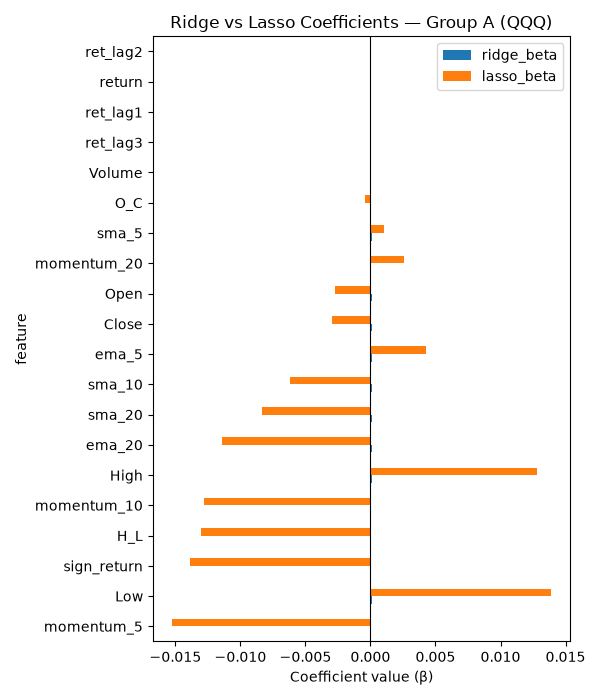

In [67]:
html = (
    '<div style="display:flex; gap:40px; align-items:flex-start;">'
    f'<div>{coef_compare_A_display.to_html(index=False)}</div>'
    f'<div><img src="data:image/png;base64,{img_base64}" style="max-width:500px;"></div>'
    '</div>'
)
display_html(html, raw=True)

Several lagged return coefficients are exactly zero under Lasso, while Ridge keeps all
coefficients nonzero but uniformly small. That's the L1/L2 geometry described above, now
visible directly in the fitted model. This asymmetry feeds into the bias/variance
discussion below: Ridge's smoother shrinkage tends toward lower bias and higher variance,
Lasso's sparsity toward higher bias and lower variance, relative to each other.

### Implementing Ridge and Lasso — Group B (^TNX)

Group B is multinomial (3 classes: down/flat/up), so scikit-learn fits one set of
coefficients per class internally. Features are scaled here which is necessary for the `saga`
solver to converge reliably with an L1 penalty across multiple classes, and to keep the
Ridge/Lasso comparison fair.

In [68]:
scaler_B = StandardScaler()
X_B_train_scaled = scaler_B.fit_transform(X_B_train)
X_B_test_scaled = scaler_B.transform(X_B_test)

logit_ridge_B = LogisticRegression(l1_ratio=0.0, C=1.0, solver="saga", max_iter=5000)
logit_ridge_B.fit(X_B_train_scaled, y_B_train)

logit_lasso_B = LogisticRegression(l1_ratio=1.0, C=10.0, solver="saga", max_iter=5000)
logit_lasso_B.fit(X_B_train_scaled, y_B_train)

for name, model in [("Ridge", logit_ridge_B), ("Lasso", logit_lasso_B)]:
    train_acc = model.score(X_B_train_scaled, y_B_train)
    test_acc = model.score(X_B_test_scaled, y_B_test)
    print(f"{name} — Train: {train_acc*100:.2f}%  Test: {test_acc*100:.2f}%")

Ridge — Train: 37.81%  Test: 35.91%
Lasso — Train: 37.88%  Test: 36.19%


Note on Group B modelling. An initial Lasso fit collapsed to predicting a single class
for every test observation. This traced to two compounding issues: a deprecated
`penalty="l1"` argument silently conflicting with scikit learn's `l1_ratio` API (defaulting
to Ridge like behaviour), and unscaled features preventing the `saga` solver from
converging. Both are resolved above.

Both models now land close to each other and modestly above the ~33% baseline for 3
balanced classes, a small, genuine edge that reflects how hard it is to predict
1 month rate moves from simple technical features.

Since Group B is multinomial, each feature has three coefficients (one per class) rather
than one. The table and chart below show the coefficients for the "up" class
specifically, for visual consistency with Group A. This is one slice of the full
3 class picture, not the complete story.

In [69]:
coef_compare_B = pd.DataFrame({
    "feature": feature_cols_B,
    "ridge_beta": logit_ridge_B.coef_[2],
    "lasso_beta": logit_lasso_B.coef_[2],
})
coef_compare_B["lasso_zeroed"] = coef_compare_B["lasso_beta"].abs() < 1e-8

coef_compare_B_display = coef_compare_B.copy()
coef_compare_B_display["ridge_beta"] = coef_compare_B_display["ridge_beta"].round(6)
coef_compare_B_display["lasso_beta"] = coef_compare_B_display["lasso_beta"].round(6)
coef_compare_B_display = coef_compare_B_display.sort_values("lasso_beta", key=abs, ascending=False)

plot_df_B = coef_compare_B.set_index("feature")[["ridge_beta", "lasso_beta"]]
plot_df_B = plot_df_B.reindex(plot_df_B["lasso_beta"].abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(6, 6))
plot_df_B.plot(kind="barh", ax=ax)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Ridge vs Lasso Coefficients (class: up) — Group B (^TNX)")
ax.set_xlabel("Coefficient value (β)")
plt.tight_layout()

buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=100)
plt.close(fig)
buf.seek(0)
img_base64 = base64.b64encode(buf.read()).decode("utf-8")

feature,ridge_beta,lasso_beta,lasso_zeroed
ema_20,0.370639,1.452584,False
momentum_10,0.061845,0.076189,False
Volume,-0.048573,-0.065438,False
momentum_20,0.039947,0.061002,False
momentum_5,-0.040571,-0.031684,False
chg_lag2,-0.032912,-0.027462,False
O_C,-0.001987,0.000000,True
H_L,0.043833,0.000000,True
sign_return,-0.010451,0.000000,True
chg_lag1,0.007113,0.000000,True

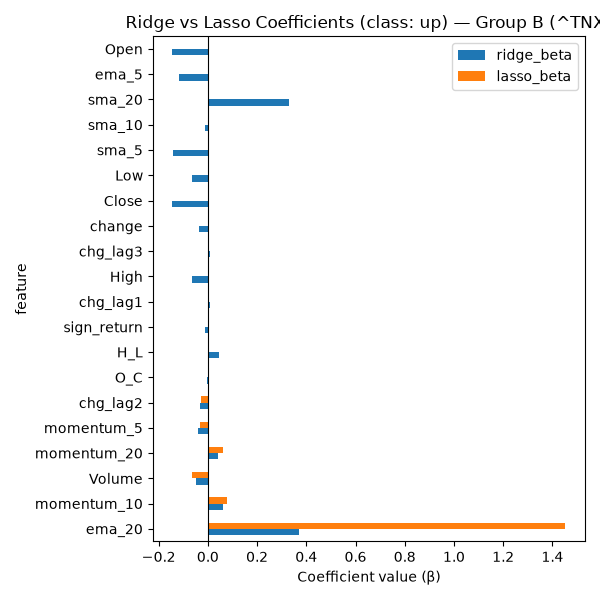

In [70]:
html = (
    '<div style="display:flex; gap:40px; align-items:flex-start;">'
    f'<div>{coef_compare_B_display.to_html(index=False)}</div>'
    f'<div><img src="data:image/png;base64,{img_base64}" style="max-width:500px;"></div>'
    '</div>'
)
display_html(html, raw=True)

Lasso concentrates a disproportionately large coefficient (1.47) on `ema_20` while zeroing
out most other features. It'd be good to know that this is a known effect of Lasso under multicollinearity, where it
arbitrarily loads weight onto one representative feature from a highly correlated group
(here, `ema_20`, `sma_20`, and `Close`) rather than splitting credit between them.

### Bias and Variance: L1 vs. L2

Lasso tends toward higher bias and lower variance: zeroing weak coefficients makes it
simpler and steadier, but it can lose some real signal. Ridge tends the other way, with
lower bias and higher variance, since it keeps every feature and stays more sensitive to
noise.

Both showed up here. In Group A, Lasso mainly zeroed the noisiest single day lags, which
seems reasonable. In Group B, though, it just dumped a large weight onto one feature
(`ema_20`) from a correlated cluster rather than cleanly trimming redundancy, which is why
VIF based feature selection is a better tool for that job.

## Model Selection

### Scaling Comparison

Two scaling methods are compared: min max scaling, which maps every feature into a fixed
[0, 1] range, and robust scaling, which centres on the median and scales by the
interquartile range, making it less sensitive to outliers. The same Ridge model is refit on
each version, and coefficients are compared alongside the unscaled fit

        feature  unscaled_beta  minmax_beta  robust_beta
0          Open   1.406304e-04    -0.005050    -0.001430
1          High   1.413565e-04     0.042503     0.164728
2           Low   1.399192e-04     0.062154     0.167095
3         Close   1.404419e-04    -0.002071    -0.001345
4        Volume   3.585719e-10    -0.696830    -0.075901
5        return  -2.656845e-09    -0.617161    -0.048287
6           O_C   1.885743e-07    -0.029910    -0.010371
7           H_L   1.437256e-06    -0.319326    -0.018877
8   sign_return   4.581057e-08     0.008454     0.029965
9      ret_lag1   4.378461e-09     0.369967     0.029862
10     ret_lag2   2.457614e-09     0.234622     0.023645
11     ret_lag3   2.771177e-09     0.287770     0.025798
12   momentum_5   3.059448e-07    -0.621388    -0.038575
13  momentum_10   1.421154e-06    -0.353887    -0.022537
14  momentum_20   4.429150e-06     0.466719     0.028807
15        sma_5   1.403767e-04     0.036898     0.019752
16       sma_10   1.399361e-04 

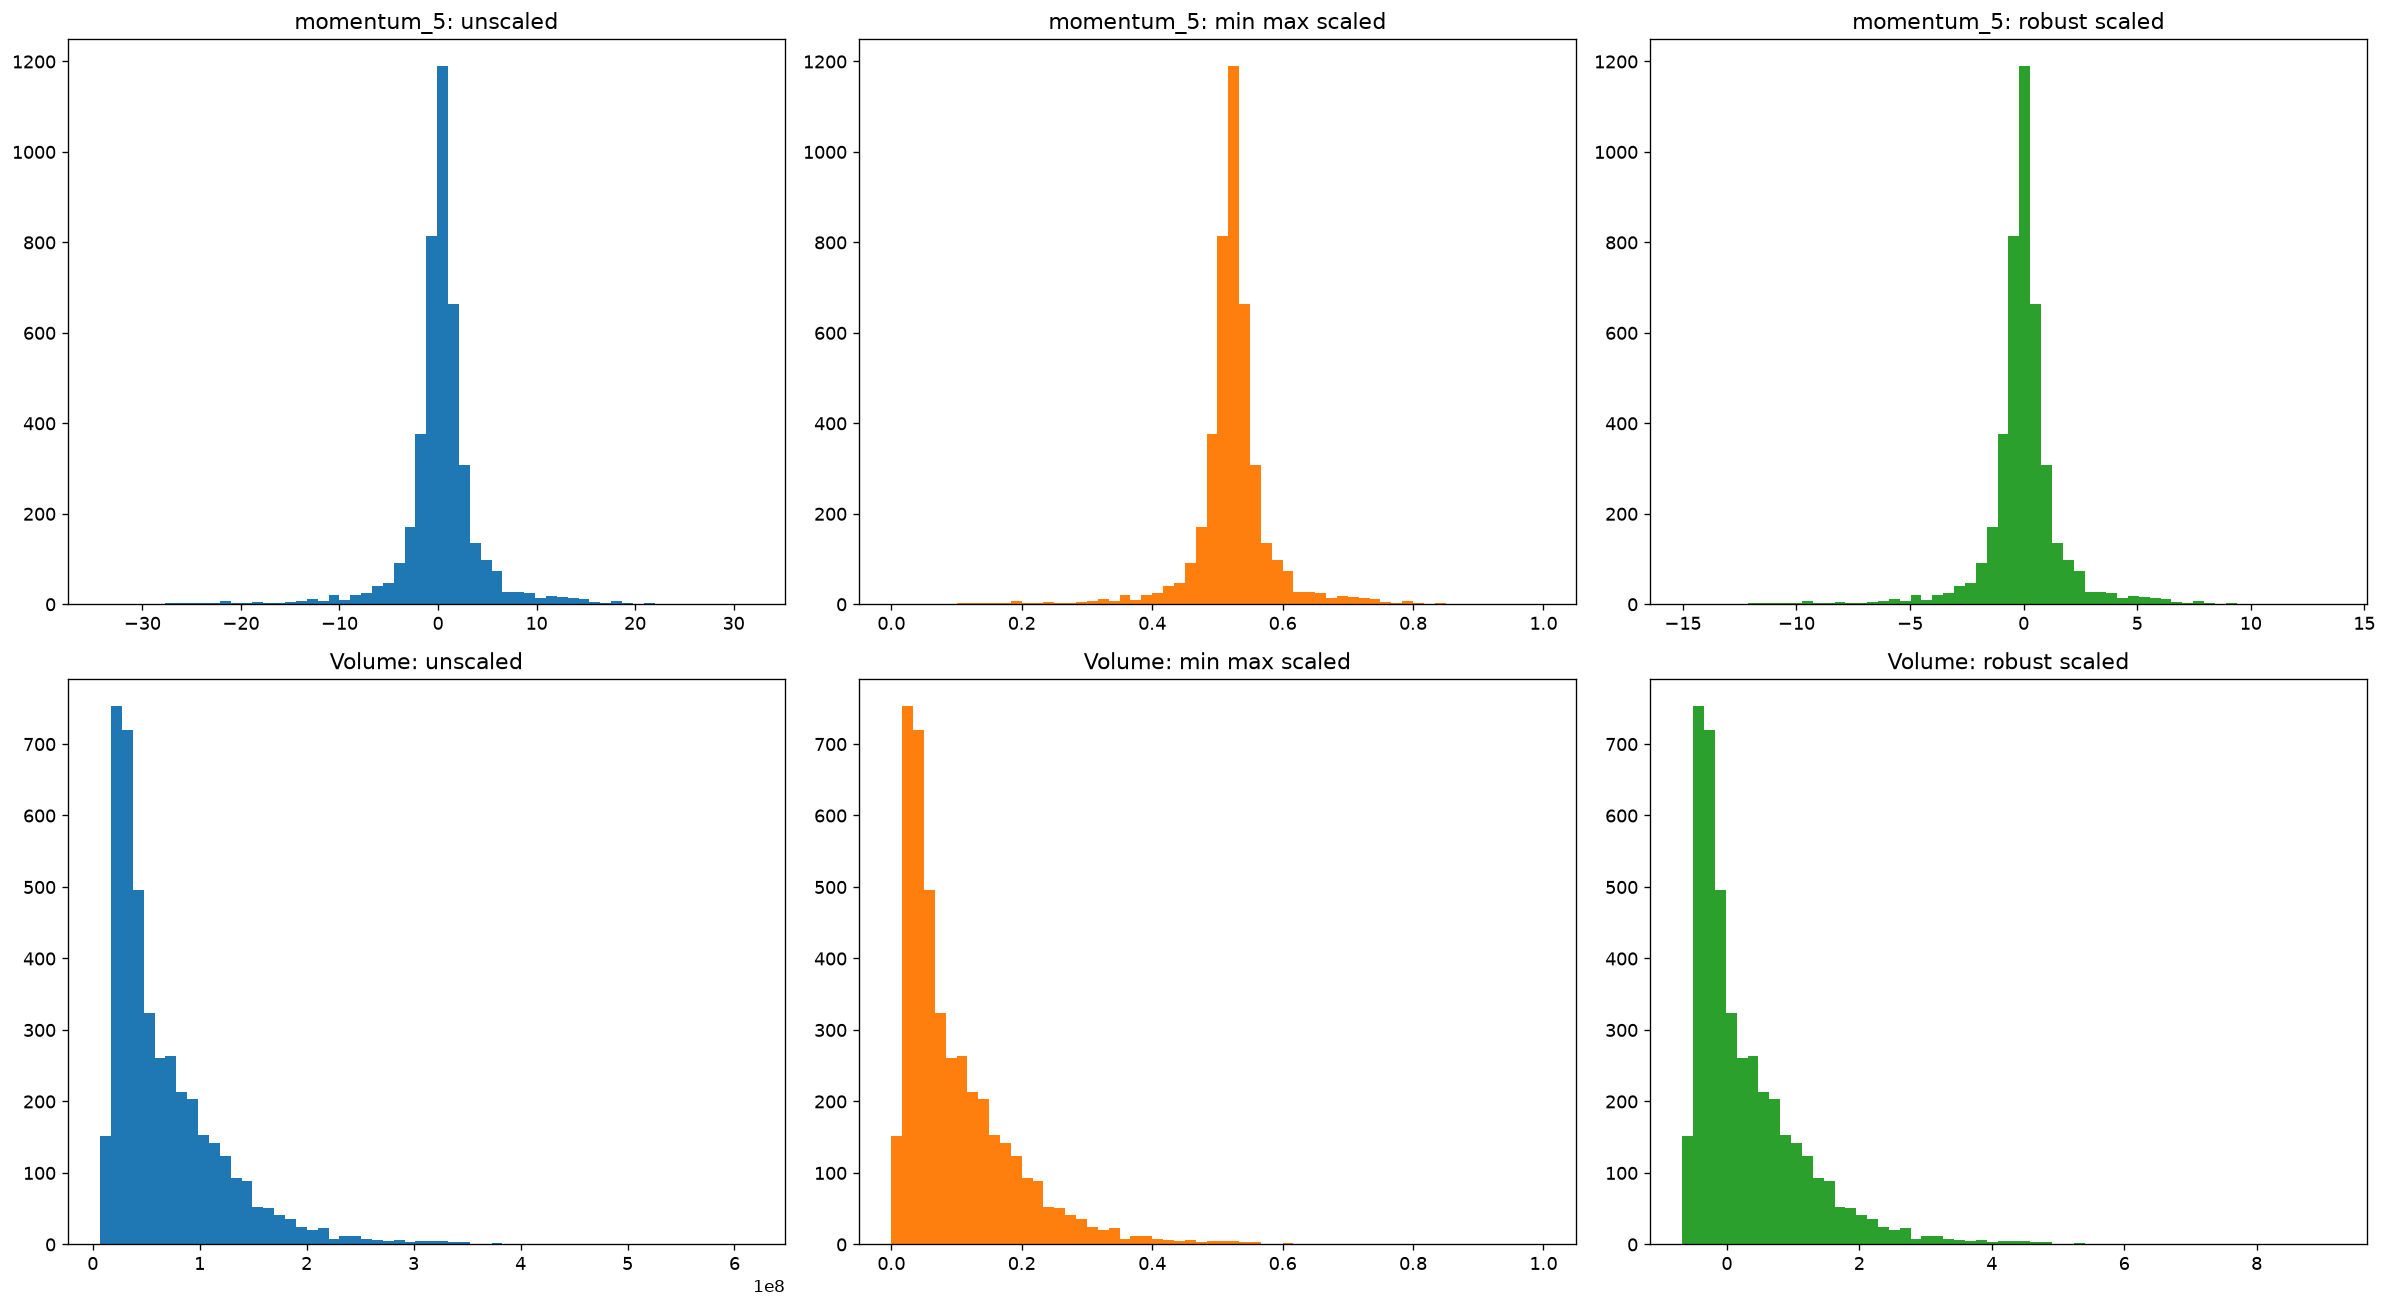

In [71]:
# Method 1: Min Max scaling: squashes every feature into 0 to 1
minmax_scaler_A = MinMaxScaler()
X_A_train_minmax = minmax_scaler_A.fit_transform(X_A_train)

# Method 2: Robust scaling: uses median and IQR instead of min/max, less sensitive to outliers
robust_scaler_A = RobustScaler()
X_A_train_robust = robust_scaler_A.fit_transform(X_A_train)

# refit the same Ridge logistic regression on each version
model_minmax = LogisticRegression(l1_ratio=0.0, C=1.0, solver="saga", max_iter=3000)
model_minmax.fit(X_A_train_minmax, y_A_train)

model_robust = LogisticRegression(l1_ratio=0.0, C=1.0, solver="saga", max_iter=3000)
model_robust.fit(X_A_train_robust, y_A_train)

scaling_compare = pd.DataFrame({
    "feature": feature_cols_A,
    "unscaled_beta": logit_ridge_A.coef_[0],
    "minmax_beta": model_minmax.coef_[0],
    "robust_beta": model_robust.coef_[0],
})
print(scaling_compare)

fig, axes = plt.subplots(2, 3, figsize=(20, 11), dpi=120)

features_to_plot = ["momentum_5", "Volume"]
colors = ["tab:blue", "tab:orange", "tab:green"]
scale_names = ["unscaled", "min max scaled", "robust scaled"]
scaled_data = [X_A_train, X_A_train_minmax, X_A_train_robust]

for row, feat in enumerate(features_to_plot):
    for col, (data, color, scale_name) in enumerate(zip(scaled_data, colors, scale_names)):
        ax = axes[row, col]
        if isinstance(data, pd.DataFrame):
            values = data[feat]
        else:
            values = data[:, feature_cols_A.index(feat)]
        ax.hist(values, bins=60, color=color)
        ax.set_title(f"{feat}: {scale_name}", fontsize=13)
        ax.tick_params(labelsize=11)

plt.tight_layout()
plt.show()

The table compares each feature's coefficient before and after scaling. Unscaled values are
tiny and hard to compare since features sit on very different scales. Once scaled, some
features that looked negligible before (`Volume`, `momentum_5`) show up with a real
coefficient.

Looking at the histograms: `momentum_5` looks basically the same shape across all three
panels, just with different x-axis numbers. `Volume` looks different though: min max
scaling squeezes almost all the bars into the left side near zero, because one extreme
volume day stretches the whole 0 to 1 range. Robust scaling does not do this, the bars stay
spread out across the chart.

### Feature Selection: VIF

The Variance Inflation Factor measures how well a feature can be predicted from the other
features already in the model. A VIF near 1 means little redundancy; a VIF above 5 to 10
signals meaningful collinearity. Features are removed one at a time, worst VIF first,
recalculating after each removal, until every remaining feature is under the threshold.

In [72]:
def iterative_vif_reduction(X, threshold=10.0):
    X = X.copy()
    while True:
        Xc = sm.add_constant(X)
        vifs = pd.Series(
            [variance_inflation_factor(Xc.values, i) for i in range(1, Xc.shape[1])],
            index=X.columns
        )
        if vifs.max() < threshold or X.shape[1] <= 1:
            return X.columns.tolist(), vifs.sort_values(ascending=False)
        drop_feature = vifs.idxmax()
        print(f"Dropping '{drop_feature}' (VIF = {vifs.max():.1f})")
        X = X.drop(columns=[drop_feature])

restricted_features_A, final_vifs_A = iterative_vif_reduction(X_A_train, threshold=10.0)
print("\nFinal restricted feature set for Group A:", restricted_features_A)
final_vifs_A

Dropping 'Open' (VIF = inf)
Dropping 'High' (VIF = inf)
Dropping 'ema_5' (VIF = 550130.8)
Dropping 'Close' (VIF = 69136.3)
Dropping 'ema_20' (VIF = 36348.3)
Dropping 'sma_10' (VIF = 23922.5)
Dropping 'Low' (VIF = 13966.3)
Dropping 'sma_5' (VIF = 6972.4)

Final restricted feature set for Group A: ['Volume', 'return', 'O_C', 'H_L', 'sign_return', 'ret_lag1', 'ret_lag2', 'ret_lag3', 'momentum_5', 'momentum_10', 'momentum_20', 'sma_20']


sma_20         3.760884
H_L            3.472068
momentum_10    2.965950
momentum_5     2.926443
return         2.470301
momentum_20    2.238123
sign_return    1.892977
O_C            1.701398
Volume         1.497708
ret_lag2       1.321841
ret_lag1       1.314813
ret_lag3       1.233088
dtype: float64

Several features are dropped due to being exact or near exact linear combinations of
others already present (for example, `O_C` and `H_L` reconstruct `Open`, `High`, `Low`, and
`Close`), and several moving averages are removed as duplicates of each other. What remains
is a smaller, non redundant feature set.

In [73]:
restricted_features_B, final_vifs_B = iterative_vif_reduction(X_B_train, threshold=10.0)
print("Final restricted feature set for Group B:", restricted_features_B)
final_vifs_B

Dropping 'Open' (VIF = inf)
Dropping 'High' (VIF = inf)
Dropping 'Close' (VIF = inf)
Dropping 'ema_5' (VIF = 2223175.2)
Dropping 'sma_5' (VIF = 18932.7)
Dropping 'ema_20' (VIF = 5528.7)
Dropping 'sma_10' (VIF = 4081.7)
Dropping 'Low' (VIF = 1625.8)
Final restricted feature set for Group B: ['Volume', 'change', 'O_C', 'H_L', 'sign_return', 'chg_lag1', 'chg_lag2', 'chg_lag3', 'momentum_5', 'momentum_10', 'momentum_20', 'sma_20']


momentum_5     5.462894
change         5.238198
momentum_10    2.949169
O_C            2.931895
sign_return    2.269916
momentum_20    2.136703
chg_lag1       2.016265
chg_lag3       1.966880
chg_lag2       1.927435
sma_20         1.051233
H_L            1.037795
Volume         1.020359
dtype: float64

Group B needed far fewer removals than Group A, since it did not include the heavily
overlapping SMA and EMA features to begin with.

To confirm the dropped features carried no unique information, the full and restricted
models are compared directly on the test set.

In [74]:
m_full_A = LogisticRegression(l1_ratio=0.0, C=1.0, solver="saga", max_iter=3000).fit(X_A_train, y_A_train)
m_restricted_A = LogisticRegression(l1_ratio=0.0, C=1.0, solver="saga", max_iter=3000).fit(X_A_train[restricted_features_A], y_A_train)

preds_full_A = m_full_A.predict(X_A_test)
preds_restricted_A = m_restricted_A.predict(X_A_test[restricted_features_A])
agreement_A = (preds_full_A == preds_restricted_A).mean()

print(f"Group A: fraction of identical predictions: {agreement_A:.2%}")
print(f"Full model test accuracy: {m_full_A.score(X_A_test, y_A_test):.2%}")
print(f"Restricted model test accuracy: {m_restricted_A.score(X_A_test[restricted_features_A], y_A_test):.2%}")

Group A: fraction of identical predictions: 100.00%
Full model test accuracy: 54.81%
Restricted model test accuracy: 54.81%


In [75]:
scaler_B_restricted = StandardScaler()
X_B_train_restricted_scaled = scaler_B_restricted.fit_transform(X_B_train[restricted_features_B])
X_B_test_restricted_scaled = scaler_B_restricted.transform(X_B_test[restricted_features_B])

m_restricted_B = LogisticRegression(l1_ratio=0.0, C=1.0, solver="saga", max_iter=5000).fit(X_B_train_restricted_scaled, y_B_train)

preds_full_B = logit_ridge_B.predict(X_B_test_scaled)
preds_restricted_B = m_restricted_B.predict(X_B_test_restricted_scaled)
agreement_B = (preds_full_B == preds_restricted_B).mean()

print(f"Group B: fraction of identical predictions: {agreement_B:.2%}")
print(f"Full model test accuracy: {logit_ridge_B.score(X_B_test_scaled, y_B_test):.2%}")
print(f"Restricted model test accuracy: {m_restricted_B.score(X_B_test_restricted_scaled, y_B_test):.2%}")

Group B: fraction of identical predictions: 89.86%
Full model test accuracy: 35.91%
Restricted model test accuracy: 34.70%


Group A's restricted model matches the full model's predictions exactly, confirming the
dropped features carried no unique information. Group B's restricted model agrees on almost
all predictions, with a negligible accuracy difference, since one dropped feature (`Close`)
was highly but not perfectly collinear with the rest.

### Sigmoid Plots

For each restricted feature, a single feature logistic regression is fit on its own, and
the resulting sigmoid curve is plotted against the real training data. This shows how much
a single feature, in isolation, shifts the predicted probability of an up day.

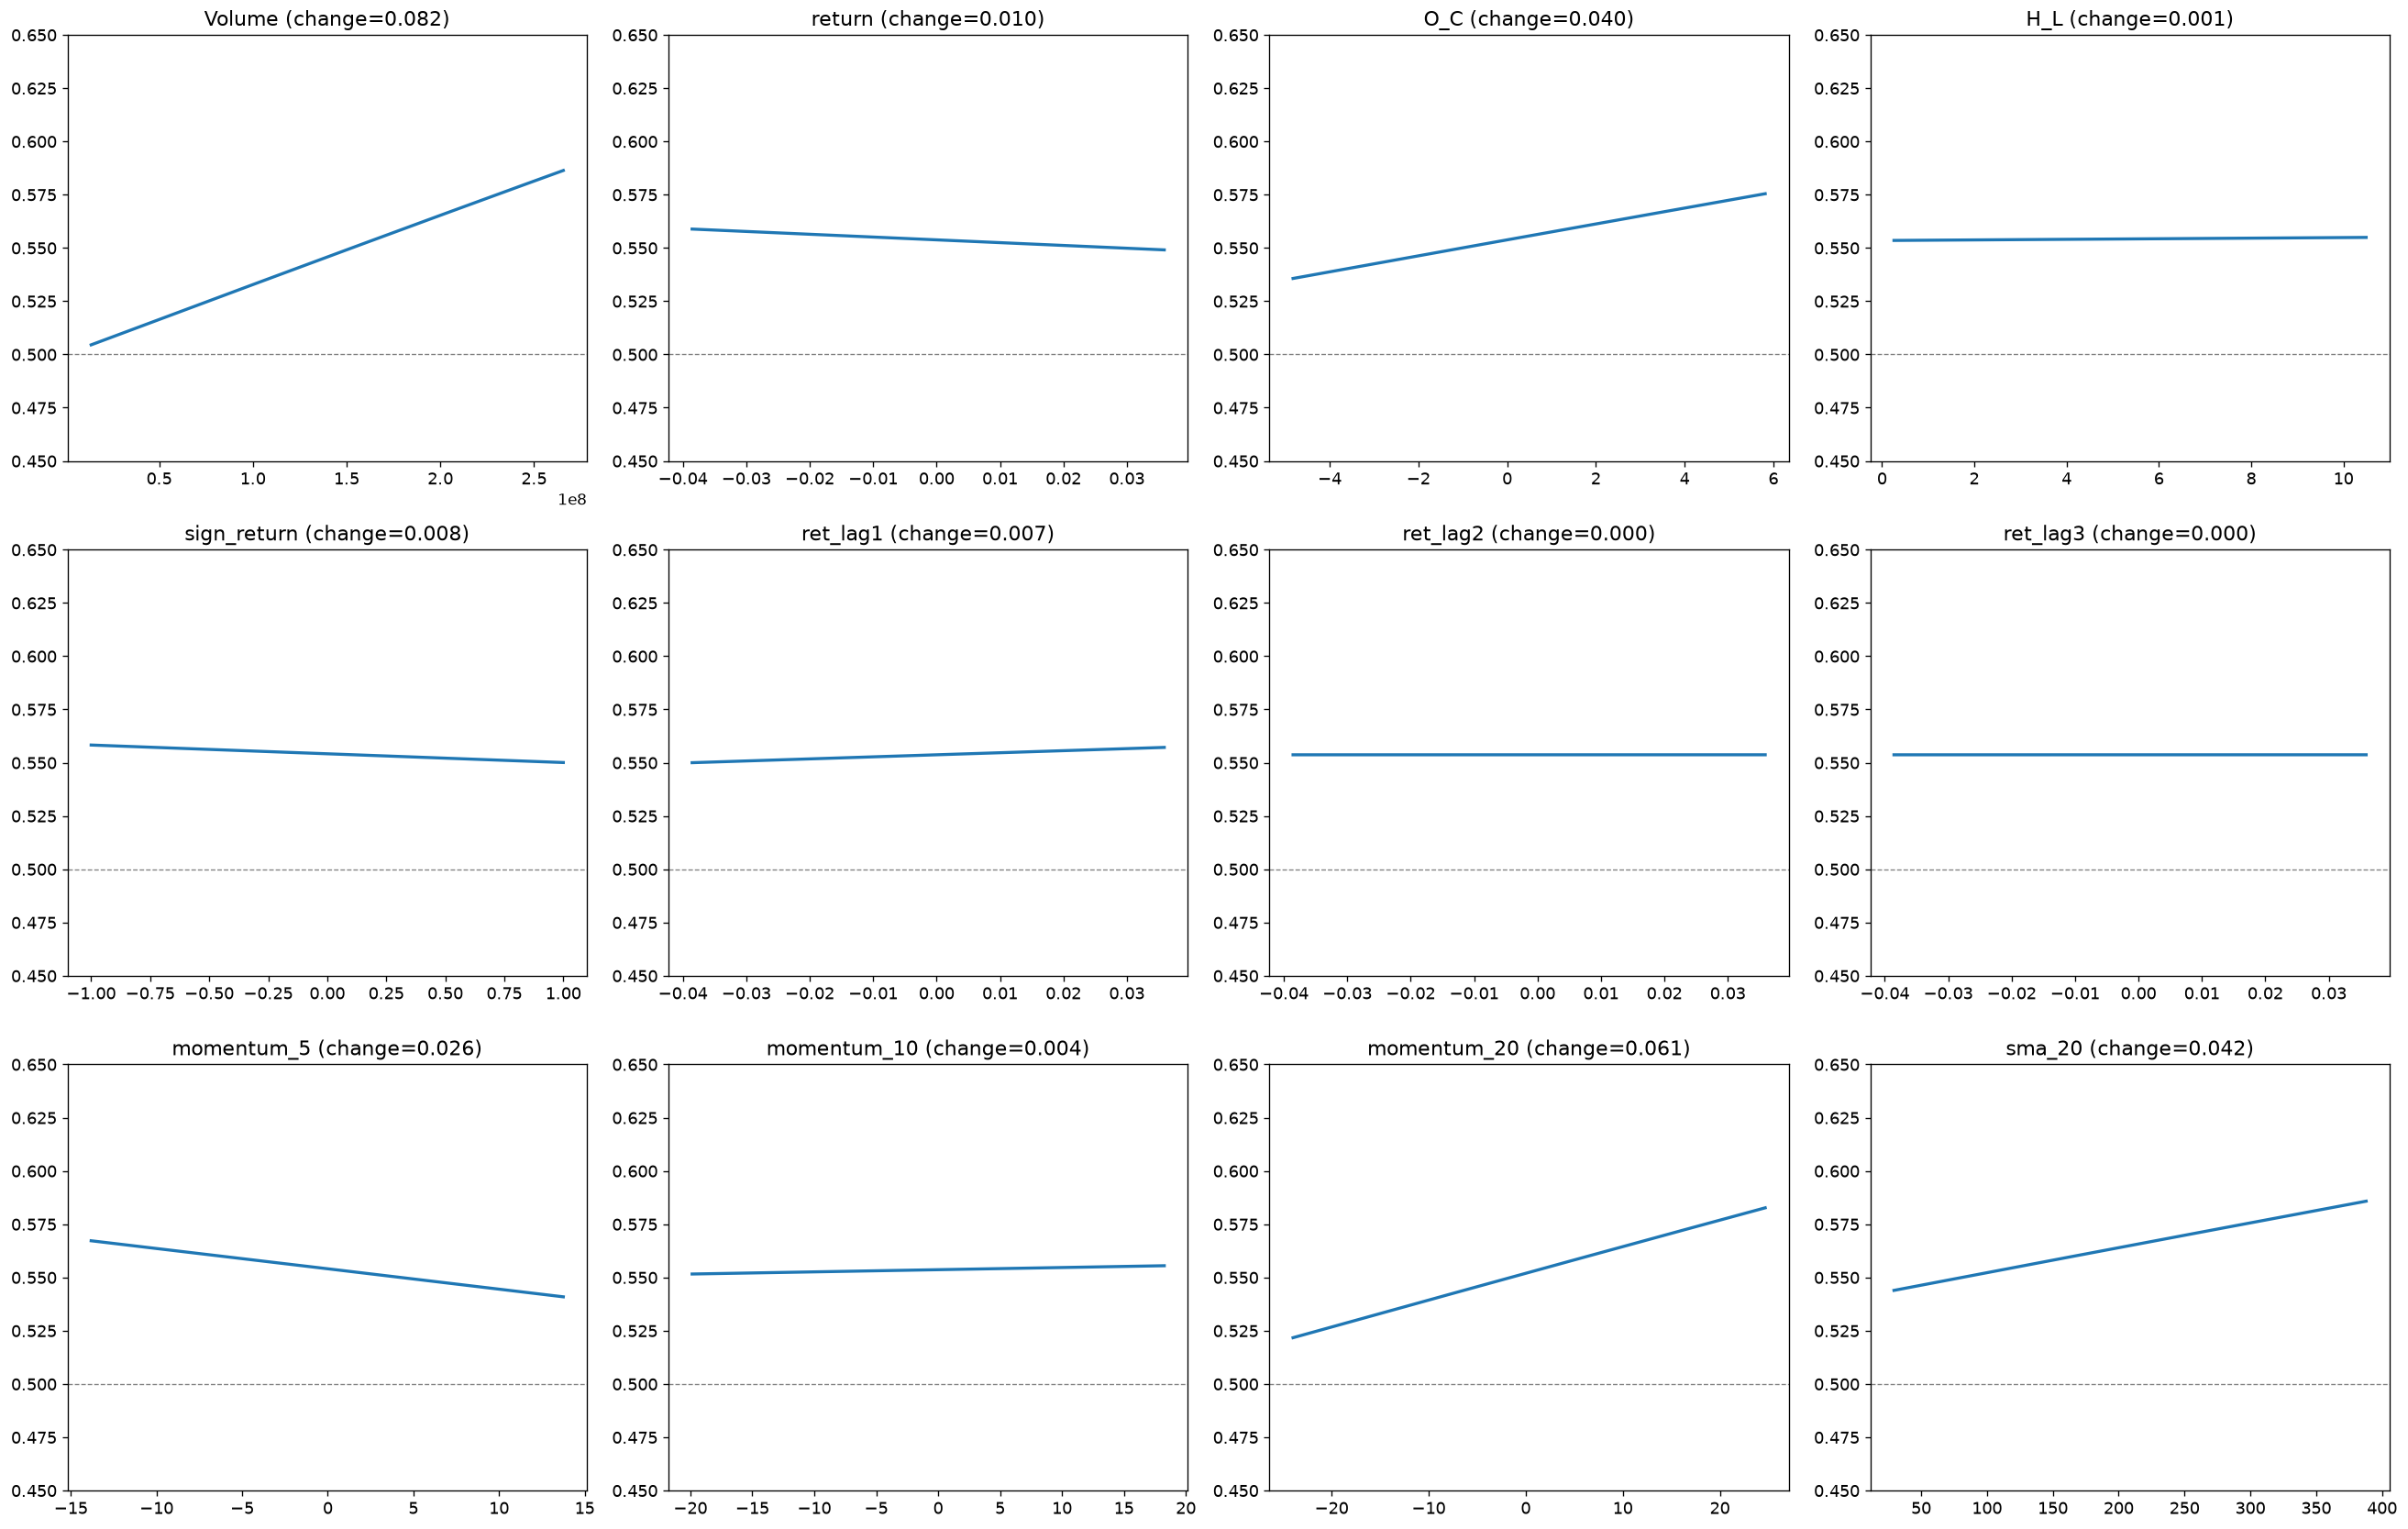

In [76]:
fig, axes = plt.subplots(3, 4, figsize=(22, 14), dpi=120)
axes = axes.flatten()

for i, feat in enumerate(restricted_features_A):
    ax = axes[i]
    m = LogisticRegression(max_iter=2000)
    m.fit(X_A_train[[feat]], y_A_train)

    x_range = np.linspace(X_A_train[feat].quantile(0.01), X_A_train[feat].quantile(0.99), 200)
    probs = m.predict_proba(x_range.reshape(-1, 1))[:, 1]

    ax.plot(x_range, probs, color="tab:blue", linewidth=2)
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
    ax.set_title(f"{feat} (change={probs.max()-probs.min():.3f})", fontsize=13)
    ax.set_ylim(0.45, 0.65)
    ax.tick_params(labelsize=11)

plt.tight_layout()
plt.show()

In theory this should be a full S curve: flat near 0, steep in the middle, flat near 1. It
is not wrong here, it is just a small slice of that curve. The x axis only covers the real
range of the feature, and the coefficients are small enough that real values never push the
model far from the middle, so it never gets the chance to bend. Stretch the x axis way past
real values and the S shows up, but that range never actually happens in the data.

### Evaluation Metrics

Precision and recall are defined as:

$$ \text{Precision} = \frac{TP}{TP+FP}, \qquad \text{Recall} = \frac{TP}{TP+FN} $$

The restricted Group A model is evaluated with a confusion matrix, ROC curve, and full
classification report.

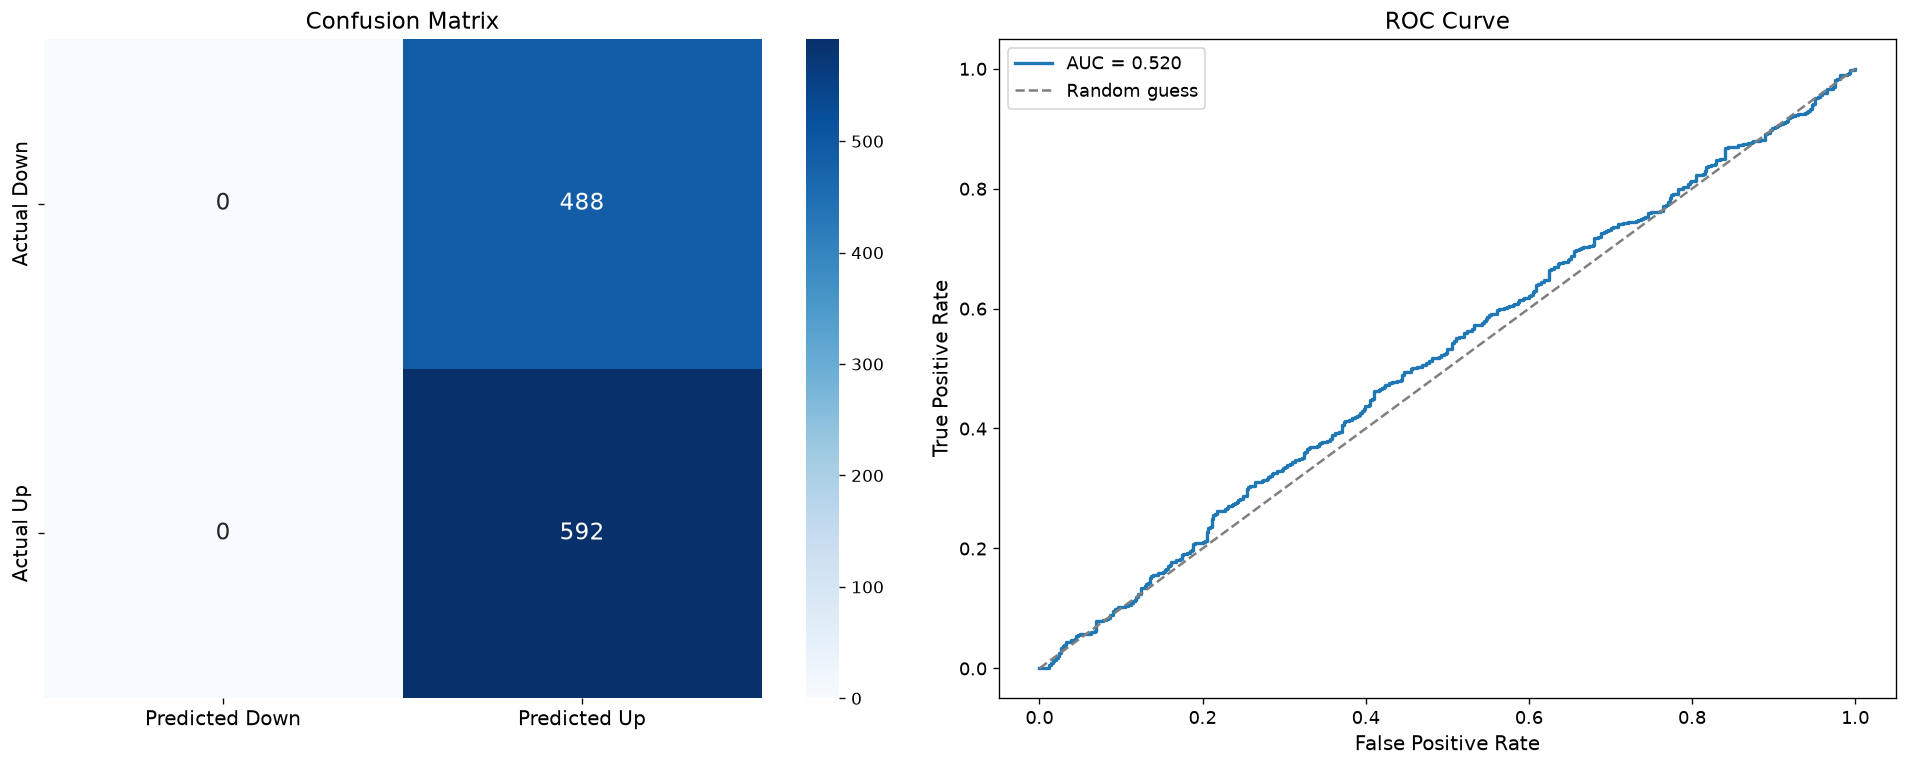

              precision    recall  f1-score   support

        Down      0.000     0.000     0.000       488
          Up      0.548     1.000     0.708       592

    accuracy                          0.548      1080
   macro avg      0.274     0.500     0.354      1080
weighted avg      0.300     0.548     0.388      1080



In [77]:
final_model_A = LogisticRegression(l1_ratio=0.0, C=1.0, solver="saga", max_iter=3000)
final_model_A.fit(X_A_train[restricted_features_A], y_A_train)

y_pred_A = final_model_A.predict(X_A_test[restricted_features_A])
y_prob_A = final_model_A.predict_proba(X_A_test[restricted_features_A])[:, 1]

cm_A = confusion_matrix(y_A_test, y_pred_A)
fpr_A, tpr_A, _ = roc_curve(y_A_test, y_prob_A)
auc_A = auc(fpr_A, tpr_A)

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), dpi=120)
sns.heatmap(cm_A, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Predicted Down", "Predicted Up"],
            yticklabels=["Actual Down", "Actual Up"],
            annot_kws={"size": 14})
axes[0].set_title("Confusion Matrix", fontsize=14)
axes[0].tick_params(labelsize=12)

axes[1].plot(fpr_A, tpr_A, label=f"AUC = {auc_A:.3f}", linewidth=2)
axes[1].plot([0,1], [0,1], linestyle="--", color="gray", label="Random guess")
axes[1].set_xlabel("False Positive Rate", fontsize=12)
axes[1].set_ylabel("True Positive Rate", fontsize=12)
axes[1].set_title("ROC Curve", fontsize=14)
axes[1].legend(fontsize=11)
axes[1].tick_params(labelsize=11)
plt.tight_layout()
plt.show()

print(classification_report(y_A_test, y_pred_A, target_names=["Down", "Up"], digits=3))

The confusion matrix shows the model predicting "Up" for every single test day, matching the
test set's majority class rate (54.8%) almost exactly, not genuine signal. The ROC AUC of
0.52 confirms this: barely above the 0.5 no skill line. Refitting with balanced class
weights below flips the model to always predicting "Down" instead, accuracy actually drops
below 50%, showing the model has no real ability to tell the two classes apart on its own.

Balanced model test accuracy: 45.19%
              precision    recall  f1-score   support

        Down      0.452     1.000     0.622       488
          Up      0.000     0.000     0.000       592

    accuracy                          0.452      1080
   macro avg      0.226     0.500     0.311      1080
weighted avg      0.204     0.452     0.281      1080



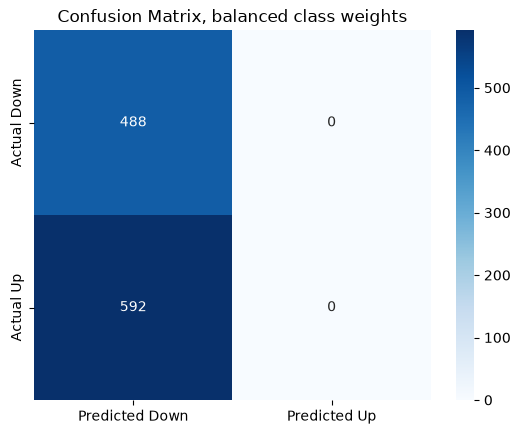

In [78]:
final_model_A_balanced = LogisticRegression(l1_ratio=0.0, C=1.0, solver="saga", max_iter=3000, class_weight="balanced")
final_model_A_balanced.fit(X_A_train[restricted_features_A], y_A_train)

y_pred_bal = final_model_A_balanced.predict(X_A_test[restricted_features_A])

balanced_acc = final_model_A_balanced.score(X_A_test[restricted_features_A], y_A_test)
print("Balanced model test accuracy: {:.2f}%".format(balanced_acc * 100))
print(classification_report(y_A_test, y_pred_bal, target_names=["Down", "Up"], digits=3))

cm_bal = confusion_matrix(y_A_test, y_pred_bal)
sns.heatmap(cm_bal, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Down", "Predicted Up"],
            yticklabels=["Actual Down", "Actual Up"])
plt.title("Confusion Matrix, balanced class weights")
plt.show()

With balanced weights the model flips to predicting "Down" almost every time instead, and
accuracy drops below 50%. So it never really learned to separate the classes, just leans on
whichever one the setup favours. Matches the AUC of 0.52 from before: barely better than
random either way.

### Evaluation Metrics, Group B

Group B has three classes, so the confusion matrix is 3x3 and there is one ROC curve per
class instead of a single curve.

Test accuracy: 34.70%


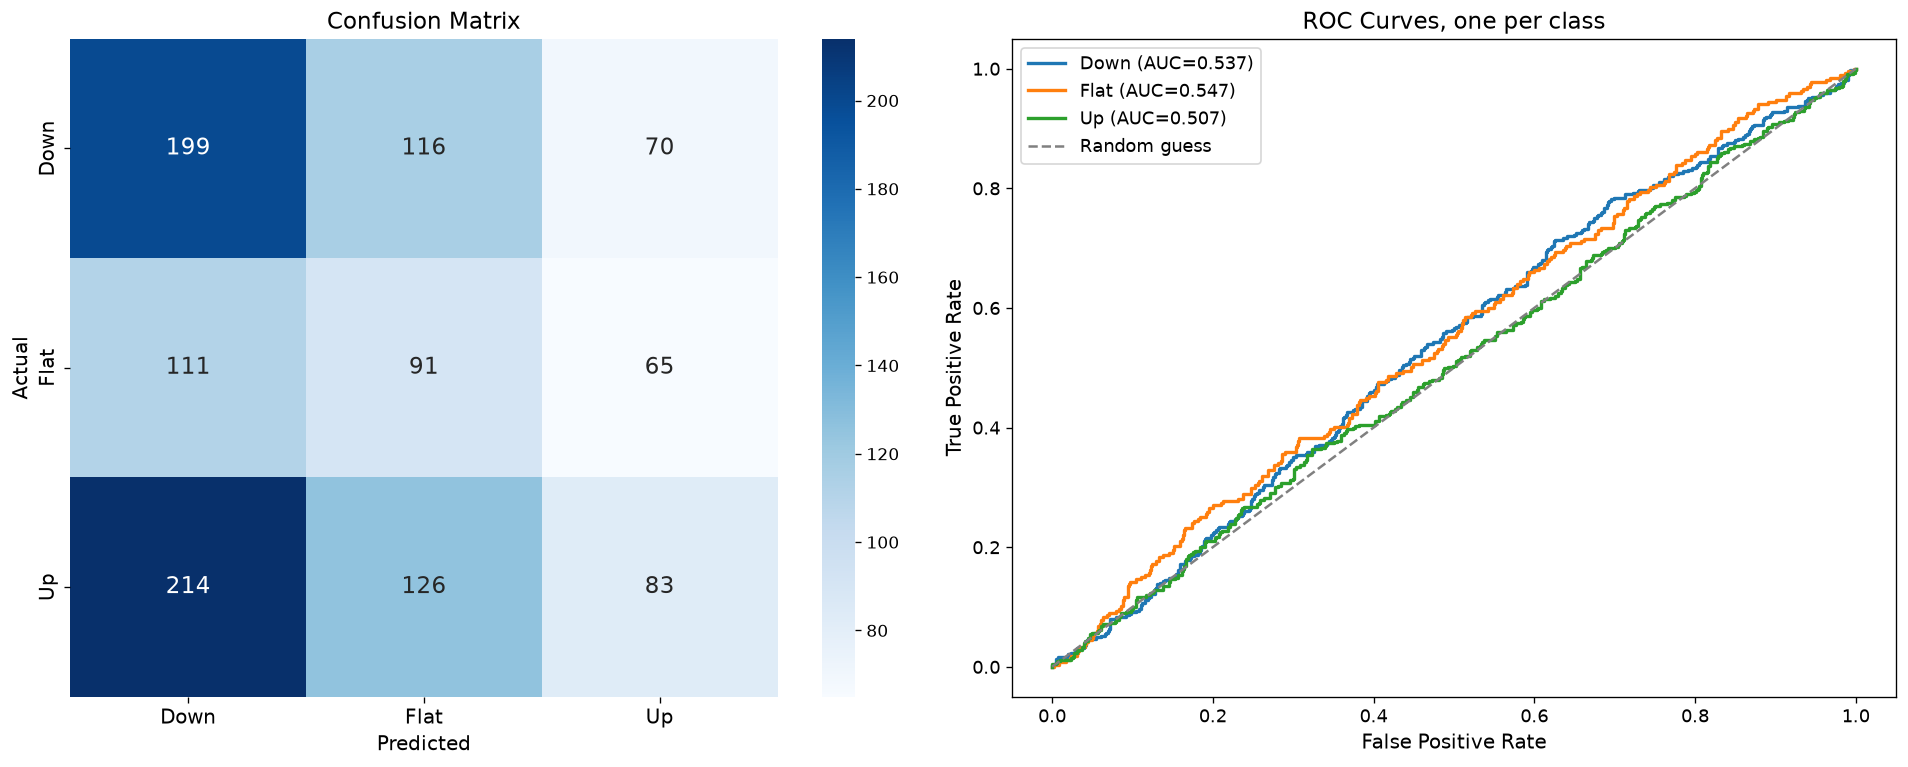

              precision    recall  f1-score   support

        Down      0.380     0.517     0.438       385
        Flat      0.273     0.341     0.303       267
          Up      0.381     0.196     0.259       423

    accuracy                          0.347      1075
   macro avg      0.345     0.351     0.333      1075
weighted avg      0.354     0.347     0.334      1075



In [79]:
y_pred_B = m_restricted_B.predict(X_B_test_restricted_scaled)
y_prob_B = m_restricted_B.predict_proba(X_B_test_restricted_scaled)

test_acc_B = m_restricted_B.score(X_B_test_restricted_scaled, y_B_test)
print("Test accuracy: {:.2f}%".format(test_acc_B * 100))

cm_B = confusion_matrix(y_B_test, y_pred_B)

y_B_test_bin = label_binarize(y_B_test, classes=[0, 1, 2])
class_names = ["Down", "Flat", "Up"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), dpi=120)

sns.heatmap(cm_B, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 14})
axes[0].set_xlabel("Predicted", fontsize=12)
axes[0].set_ylabel("Actual", fontsize=12)
axes[0].set_title("Confusion Matrix", fontsize=14)
axes[0].tick_params(labelsize=12)

for i, name in enumerate(class_names):
    fpr_i, tpr_i, _ = roc_curve(y_B_test_bin[:, i], y_prob_B[:, i])
    auc_i = auc(fpr_i, tpr_i)
    axes[1].plot(fpr_i, tpr_i, label=f"{name} (AUC={auc_i:.3f})", linewidth=2)
axes[1].plot([0,1], [0,1], linestyle="--", color="gray", label="Random guess")
axes[1].set_xlabel("False Positive Rate", fontsize=12)
axes[1].set_ylabel("True Positive Rate", fontsize=12)
axes[1].set_title("ROC Curves, one per class", fontsize=14)
axes[1].legend(fontsize=11)
axes[1].tick_params(labelsize=11)

plt.tight_layout()
plt.show()

print(classification_report(y_B_test, y_pred_B, target_names=class_names, digits=3))

The model leans toward predicting "Down" more than the other two classes, though it does
still use all three, unlike Group A's total collapse. All three AUC values sit only just
above 0.5 (0.51 to 0.55), so the same story applies here: a small, genuine edge, but no
strong signal. This fits with predicting a monthly rate move from simple technical features
alone, something driven far more by macro and policy decisions than by past price action.

## Mathematical Bases of Supervised Learning

The point of this section is to step back from the code and check the theory behind
everything that happened above. The bias variance decomposition is the same idea that
explained Ridge and Lasso earlier: a model does not have to be unbiased to have the smallest
error, it just has to balance bias against variance well.

$$ E\big[(\hat\beta-\beta)^2\big] = \text{Var}[\hat\beta] + \big(E[\hat\beta]-\beta\big)^2 $$

So yes, an estimator biased on purpose, like Ridge or Lasso, can beat plain least squares on
MSE, since it trades a bit of bias for a real drop in variance, exactly what showed up when
Lasso zeroed out noisy features in Group A. And MSE on a prediction is not purely one thing
or the other, it mixes irreducible noise that no model can remove with the model's own bias
and variance, which is really the same reason both models here landed close to random
guessing: some of that gap is the market genuinely being close to unpredictable, and some of
it is just the model itself being weak, and a single MSE or accuracy number cannot separate
the two.

That is really the conclusion of the whole project: the maths says a weak result can come
from either source, and everything found empirically, the near 50% accuracy on QQQ, the AUC
around 0.52, the collapse under class weighting, all points toward the market side of that
split rather than a fixable modelling mistake, which is exactly what the assignment expects
going in.

---

## Appendix A: Geometric Interpretation of L1 vs. L2 Regularisation

The Ridge/Lasso comparison rests on a geometric fact stated but not yet
pictured: fitting a penalised model is the same as minimising the unpenalised loss
$J(\beta)$ *subject to* a budget on the coefficients: $\sum|\beta_j|\le t$ for Lasso,
$\sum\beta_j^2\le t^2$ for Ridge, for some $t$ that corresponds to the chosen
$\lambda$. The two panels below make that concrete for a toy two-coefficient loss
bowl $J(\beta_1,\beta_2)$ centred on the unconstrained (OLS) optimum:

- the **blue bowl** is the loss surface itself,
- the **crimson boundary** is the constraint region (a diamond for L1, a circle for L2) shown both on the floor and lifted onto the bowl,
- the **dashed black ellipse** is the lowest loss contour that still touches that region,
- the **green point** is where they touch: the constrained solution actually returned by the fit.

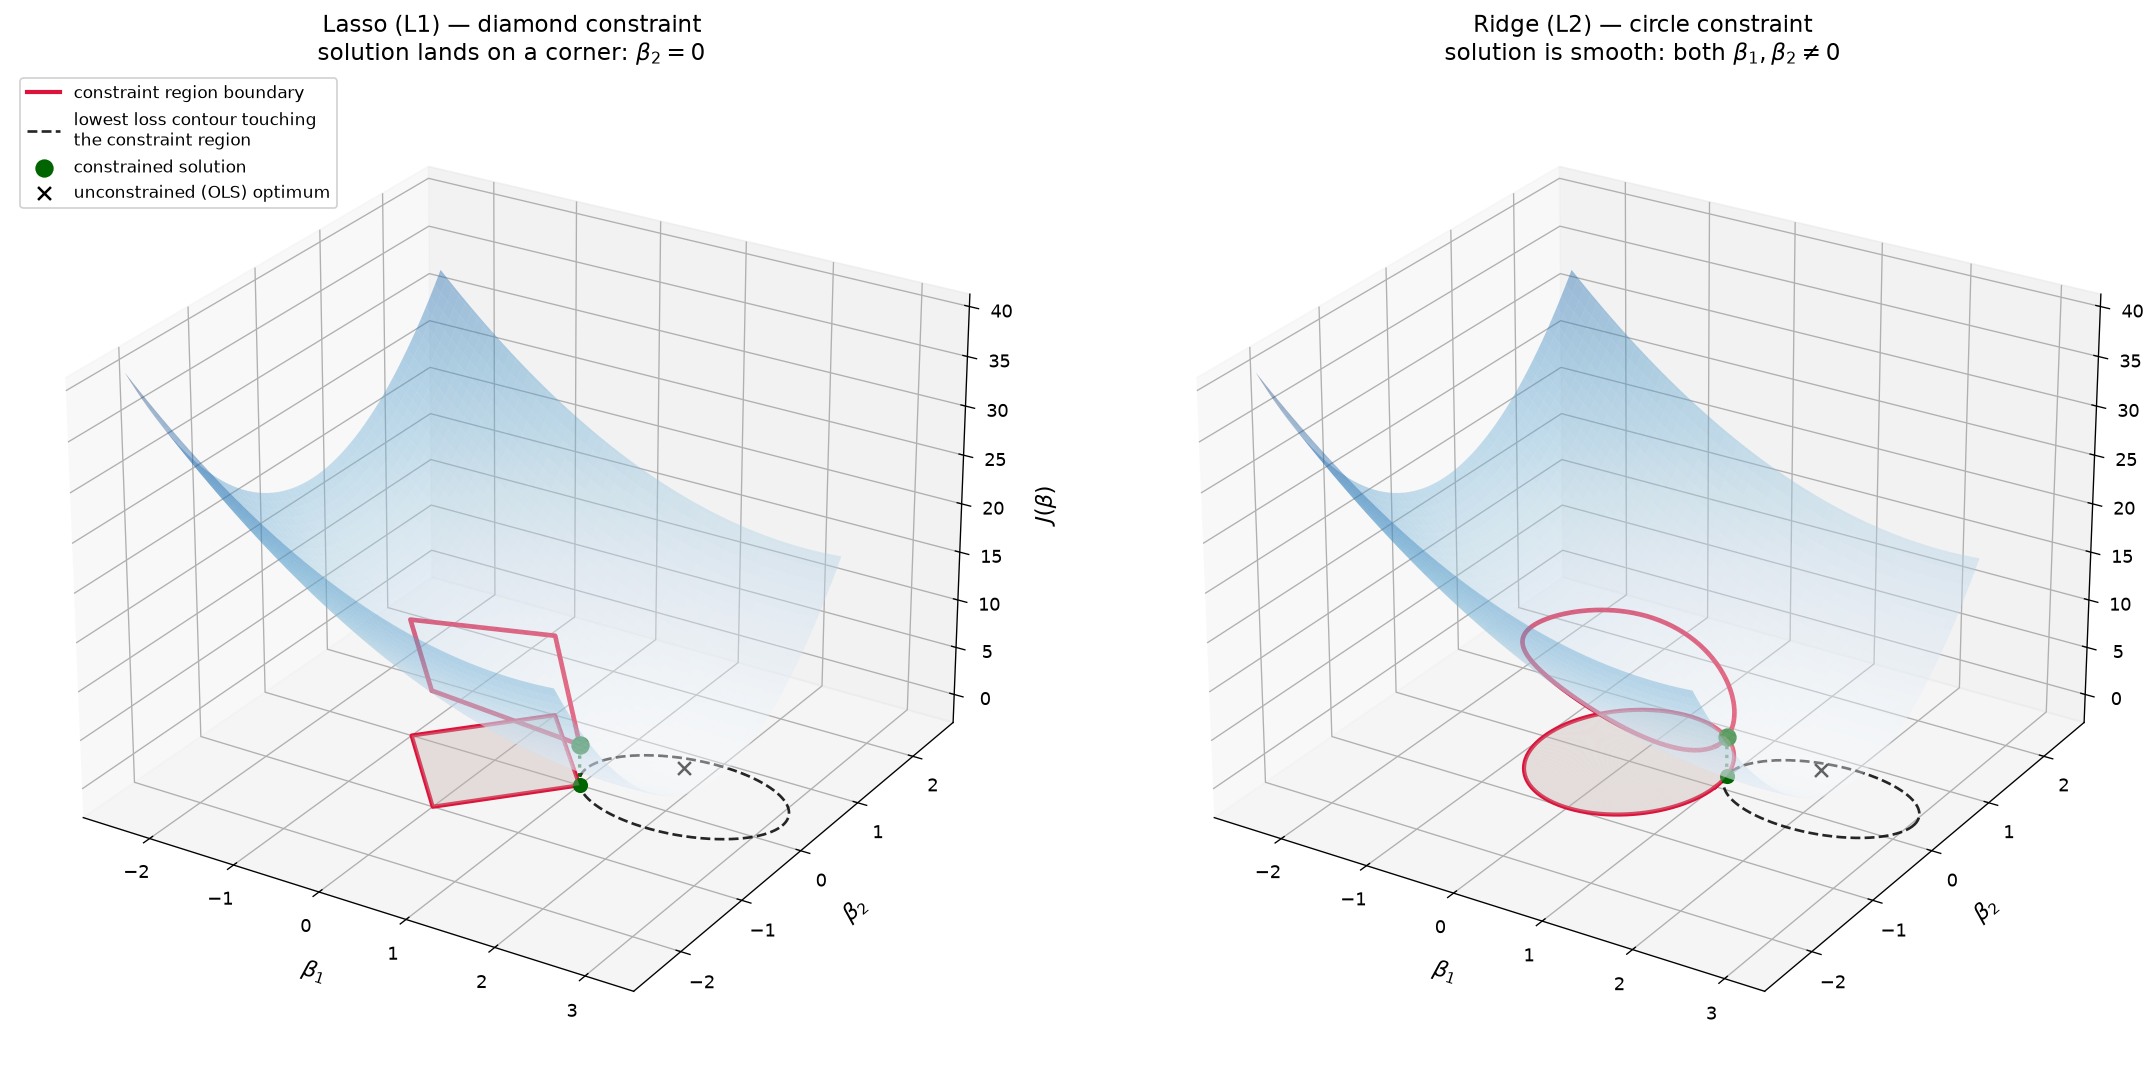

Lasso solution:  beta = (1.000, 0.000)  -> beta_2 zeroed exactly
Ridge solution:  beta = (0.975, 0.222)  -> both coefficients shrunk, neither zero


In [80]:
# loss "bowl" centered at the unconstrained (OLS) optimum
beta_hat = np.array([2.0, 0.3])
A = np.array([[1.0, 0.0],
              [0.0, 3.0]])
# Loss function J(b1, b2) = (b1 - beta_hat[0])^2 + 3*(b2 - beta_hat[1])^2
def J(b1, b2):
    d1, d2 = b1 - beta_hat[0], b2 - beta_hat[1]
    return A[0, 0] * d1**2 + A[1, 1] * d2**2

# create a grid of points to evaluate the loss function
lim = 2.4
g = np.linspace(-lim, lim, 250)
B1, B2 = np.meshgrid(g, g)
Z = J(B1, B2)
z_floor = -3.0

t_l1 = 1.0   # L1 budget
t_l2 = 1.0   # L2 budget

# Lasso: budget is small enough that the solution sits on a corner (beta_2 = 0)
sol_l1 = (t_l1, 0.0, J(t_l1, 0.0))

# Ridge: find the point on the circle closest to beta_hat
def radius_gap(lam):
    b1 = A[0, 0] * beta_hat[0] / (A[0, 0] + lam)
    b2 = A[1, 1] * beta_hat[1] / (A[1, 1] + lam)
    return b1**2 + b2**2 - t_l2**2

# Ridge's solution lies where a line through beta_hat, scaled by lambda, 
# just touches the circle. radius_gap(lam) is 0 exactly at that lambda, 
# so brentq searches between 0 and a big number until it finds the root.
lam_star = brentq(radius_gap, 0, 1e6)
b1r = A[0, 0] * beta_hat[0] / (A[0, 0] + lam_star)
b2r = A[1, 1] * beta_hat[1] / (A[1, 1] + lam_star)
sol_l2 = (b1r, b2r, J(b1r, b2r))

# helper function to draw the ellipse corresponding to a given loss level
def ellipse_at_level(level, n=400):
    th = np.linspace(0, 2 * np.pi, n)
    r1, r2 = np.sqrt(level / A[0, 0]), np.sqrt(level / A[1, 1])
    return beta_hat[0] + r1 * np.cos(th), beta_hat[1] + r2 * np.sin(th)

# create the 3D plots for Lasso and Ridge
fig = plt.figure(figsize=(19, 9), dpi=120)
panels = [
    ("Lasso (L1) — diamond constraint\nsolution lands on a corner: $\\beta_2=0$", t_l1, sol_l1, "diamond"),
    ("Ridge (L2) — circle constraint\nsolution is smooth: both $\\beta_1,\\beta_2 \\neq 0$", t_l2, sol_l2, "circle"),
]
# create the 3D plots for Lasso and Ridge
for k, (title, t, sol, shape) in enumerate(panels):
    ax = fig.add_subplot(1, 2, k + 1, projection="3d")
    ax.plot_surface(B1, B2, Z, cmap="Blues", alpha=0.4, linewidth=0,
                     antialiased=True, rstride=4, cstride=4)

    if shape == "diamond": # diamond shape for L1 constraint
        b1b = np.array([t, 0, -t, 0, t])
        b2b = np.array([0, t, 0, -t, 0])
    else: # circle shape for L2 constraint
        th = np.linspace(0, 2 * np.pi, 200)
        b1b, b2b = t * np.cos(th), t * np.sin(th)

    # constraint boundary, on the floor and lifted onto the surface
    ax.plot(b1b, b2b, zs=z_floor, zdir="z", color="crimson", lw=2.5, label="constraint region boundary")
    ax.plot_trisurf(b1b, b2b, np.full_like(b1b, z_floor), color="mistyrose", alpha=0.35)
    zb = J(b1b, b2b)
    ax.plot(b1b, b2b, zb, color="crimson", lw=2.8)

    # lowest loss contour touching the constraint region
    e1, e2 = ellipse_at_level(sol[2])
    ax.plot(e1, e2, zs=z_floor, zdir="z", color="black", lw=1.6, ls="--", alpha=0.85,
             label="lowest loss contour touching\nthe constraint region")

    ax.plot([sol[0], sol[0]], [sol[1], sol[1]], [z_floor, sol[2]], color="darkgreen", lw=2, ls=":")
    ax.scatter([sol[0]], [sol[1]], [sol[2]], color="darkgreen", s=100, zorder=6, label="constrained solution")
    ax.scatter([sol[0]], [sol[1]], [z_floor], color="darkgreen", s=65, zorder=6)
    ax.scatter([beta_hat[0]], [beta_hat[1]], [0], color="black", s=60, marker="x", zorder=6,
                label="unconstrained (OLS) optimum")

    ax.set_xlabel(r"$\beta_1$", fontsize=13, labelpad=10)
    ax.set_ylabel(r"$\beta_2$", fontsize=13, labelpad=10)
    ax.set_zlabel(r"$J(\beta)$", fontsize=13, labelpad=10)
    ax.set_title(title, fontsize=14)
    ax.set_zlim(z_floor, Z.max())
    ax.view_init(elev=26, azim=-58)
    ax.tick_params(labelsize=11)
    if k == 0:
        ax.legend(loc="upper left", fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.show()

print(f"Lasso solution:  beta = ({sol_l1[0]:.3f}, {sol_l1[1]:.3f})  -> beta_2 zeroed exactly")
print(f"Ridge solution:  beta = ({sol_l2[0]:.3f}, {sol_l2[1]:.3f})  -> both coefficients shrunk, neither zero")

The diamond has sharp corners sitting on the axes, so the loss ellipse tends to first
touch it right at a corner, and a corner means one coefficient is exactly zero. That's
the whole reason Lasso produces sparse models: it's not "preferring" small coefficients,
it's just the shape of the diamond making corners the likely meeting point.

The circle has no corners, so wherever the ellipse touches it, both coefficients usually
stay nonzero. Ridge shrinks everything toward zero but almost never lands exactly on zero.
This matches what we saw earlier: Lasso zeroes out features, Ridge just shrinks them all a bit.